## Setup

In [197]:
%load_ext autoreload
%autoreload 2

# Other useful imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal as signal
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA, FastICA
import time
from scipy.signal import welch
from IPython.display import clear_output
import scipy.stats as stats

# Spyeeg import
from spyeeg.generate import simulate_channels, simulate_multisensory_channels, simulate_continuous_stimuli, simulate_PAC
import spyeeg.models as models

# mtrf
from mtrf.model import TRF
from mtrf.stats import crossval
from sklearn.model_selection import KFold

# mne 
import mne

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
mpl.rcParams.update(mpl.rcParamsDefault)

%matplotlib inline
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["b", "r", "g"])
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.linewidth'] = 0.4
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['font.size'] = 3.5
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['grid.alpha'] = 0.4
mpl.rcParams['grid.linewidth'] = 0.2
mpl.rcParams['lines.linewidth'] = 0.6


## Simple Case comparison

### Defaults Example

In [486]:
# Generate the Data without noise
fs = 50
n_feat = 10
n_channels = 64
T = 300
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -10, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)


In [487]:
tmin, tmax = -.5, 1
alphas = np.logspace(-4,4,10)
n_folds = 5
metrics = 'corr'

#### Spyeeg : time

In [488]:
trf_spyeeg = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')

# Now, we can fit the data using cross-fold validation
scores_spyeeg = trf_spyeeg.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)

scores_spyeeg = scores_spyeeg.mean(0).max(-1)

#### Spyeeg fourier

In [489]:
trf_spyeegfft = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')

# Now, we can fit the data using cross-fold validation
scores_spyeegfft = trf_spyeegfft.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)

scores_spyeegfft = scores_spyeegfft.mean(0).max(-1)

#### mtrf

In [490]:
kf = KFold(n_splits=n_folds)

X_fold, Y_fold = [], []
for kfold, (train, test) in enumerate(kf.split(X)):
    X_fold.append(X[test,:])
    Y_fold.append(Y[test,:])

fwd_trf = TRF(direction=1)
regularization = alphas # regularization parameter lambda
scores_mtrf = []
for regularization in alphas:
    r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
    scores_mtrf.append(r_fwd)
scores_mtrf = np.asarray(scores_mtrf).max(0)


#### Comparison

FriedmanchisquareResult(statistic=np.float64(76.59375), pvalue=np.float64(2.332805407591977e-17))
mtrf spyt 0.011490462935882174
mtrf spyf 2.8054070298609703e-11
spyt spyf 3.2083899595088915e-11


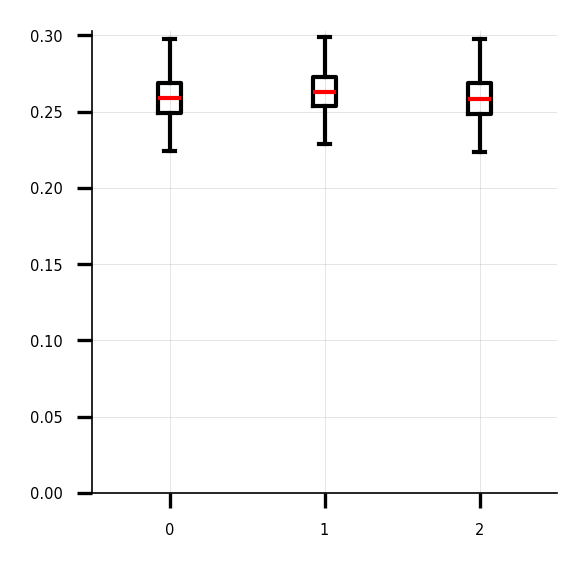

In [491]:
fig, ax = plt.subplots(figsize = (2,2))
ax.boxplot(scores_spyeeg,positions=[0], showfliers=False)
ax.boxplot(scores_spyeegfft,positions=[1], showfliers=False)
ax.boxplot(scores_mtrf,positions=[2], showfliers=False)
ax.set_ylim(0, None)

scores_all = [scores_mtrf, scores_spyeeg, scores_spyeegfft]
names_all = ['mtrf', 'spyt', 'spyf']
print(stats.friedmanchisquare(*scores_all))
for i in range(len(scores_all)):
    for j in range(i + 1, len(scores_all)):
        print(names_all[i], names_all[j], stats.wilcoxon(scores_all[i], scores_all[j], alternative = 'less')[1])


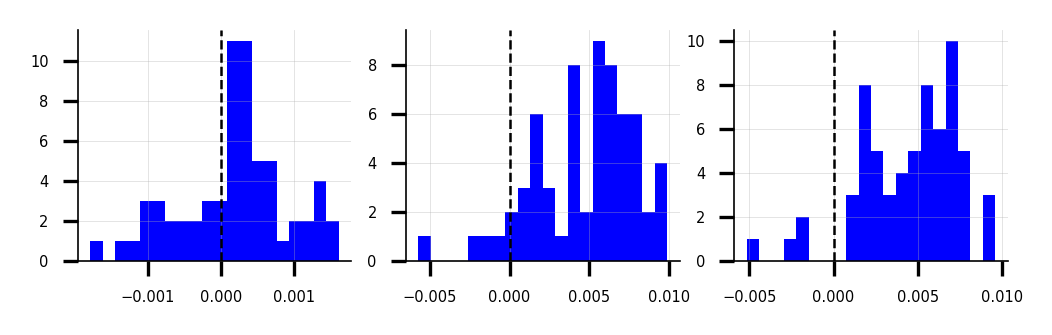

In [492]:
fig, ax = plt.subplots(1,3,figsize = (4,1))
bins = 20
ax[0].hist(scores_spyeeg - scores_mtrf, bins = bins)
ax[1].hist(scores_spyeegfft - scores_mtrf, bins = bins)
ax[2].hist(scores_spyeegfft - scores_spyeeg, bins = bins)

for i in range(3):
    ax[i].axvline(0, color = 'k', ls = '--')

### As a function of the SNR

In [514]:
snr_list = np.arange(-30,30,5)
fs = 50
n_feat = 5
n_channels = 64
T = 300

tmin, tmax = -.5, 1
alphas = np.logspace(-4,4,10)
n_folds = 5
metrics = 'corr'

scores_spyt, scores_spyf, scores_mtrf = [],[],[]
for snr in snr_list:
    time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                                stim_type = 'continuous',
                                                                snr_db = snr, beta_noise = 0.4, 
                                                                impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                                delays = [0.00,0.2], 
                                                                filter_impulse = False, filter_val = [0.01,20],
                                                                random_seed = 0)

    trf_spyt = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')
    score_spyt = trf_spyt.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    score_spyt = score_spyt.mean(0).max(-1)
    scores_spyt.append(score_spyt)


    trf_spyf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')
    score_spyf = trf_spyf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    score_spyf = score_spyf.mean(0).max(-1)
    scores_spyf.append(score_spyf)


    kf = KFold(n_splits=n_folds)
    X_fold, Y_fold = [], []
    for kfold, (train, test) in enumerate(kf.split(X)):
        X_fold.append(X[test,:])
        Y_fold.append(Y[test,:])

    fwd_trf = TRF(direction=1)
    regularization = alphas # regularization parameter lambda
    score_mtrf = []
    for regularization in alphas:
        r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
        score_mtrf.append(r_fwd)
    score_mtrf = np.asarray(score_mtrf).max(0)
    scores_mtrf.append(score_mtrf)

    

Text(0, 0.5, 'Processing time (s)')

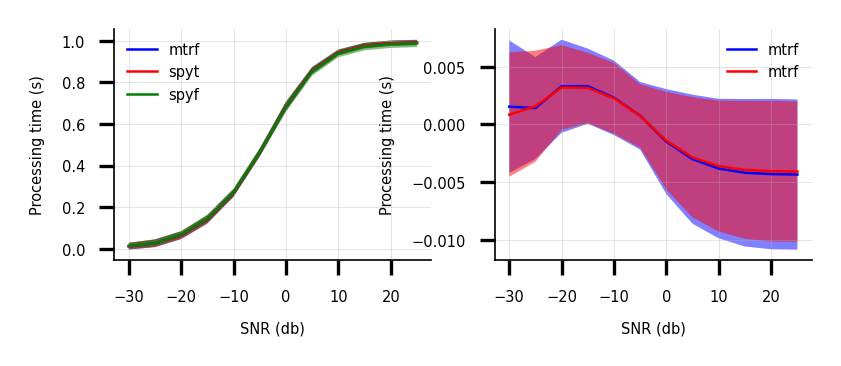

In [518]:
scores_all = np.asarray([scores_mtrf, scores_spyt, scores_spyf])
names_all = ['mtrf', 'spyt','spyf']

fig, axes = plt.subplots(1,2,figsize = (3,1))
ax = axes[0]
for i in range(3):
    data = scores_all[i]
    ax.plot(snr_list,data.mean(1), label = names_all[i])
    ax.fill_between(snr_list,
                    data.mean(1) - data.std(1),
                    data.mean(1) + data.std(1),
                    alpha = 0.5)
ax.legend(framealpha = 0)
ax.set_xlabel('SNR (db)')
ax.set_ylabel('Processing time (s)')

ax = axes[1]
for i in range(2):
    data = (scores_all[2] - scores_all[i])
    ax.plot(snr_list,data.mean(1), label = 'mtrf')
    ax.fill_between(snr_list,
                    data.mean(1) - data.std(1),
                    data.mean(1) + data.std(1),
                    alpha = 0.5)
ax.legend(framealpha = 0)
ax.set_xlabel('SNR (db)')
ax.set_ylabel('Processing time (s)')

## Speed and CPU usage Comparison

### Relative to numbers of regularization parameters

In [477]:
# Generate the Data without noise
fs = 50
n_feat = 3
n_channels = 64
T = 300
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)

tmin, tmax = -.5, 1
n_folds = 5
metrics = 'corr'

In [478]:
t_spyf, t_spyt, t_mtrf = [],[],[]
cpu_spyf_l, cpu_spyt_l, cpu_mtrf_l = [], [], []
core_spyf_l, core_spyt_l, core_mtrf_l = [], [], []
list_nreg = np.arange(1,201,20) 
for n_reg in list_nreg:
    alphas = np.logspace(-4,4,n_reg)

    trf_spyt = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')
    w0_spyt = time.perf_counter()
    c0_spyt = time.process_time()
    scores_spyt = trf_spyt.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyt = time.perf_counter()
    c1_spyt = time.process_time()
    wall_spyt = w1_spyt - w0_spyt
    cpu_spyt  = c1_spyt - c0_spyt

    trf_spyf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')
    w0_spyf = time.perf_counter()
    c0_spyf = time.process_time()
    scores_spyf = trf_spyf.xval_eval(X, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyf = time.perf_counter()
    c1_spyf = time.process_time()
    wall_spyf = w1_spyf - w0_spyf
    cpu_spyf  = c1_spyf - c0_spyf

    kf = KFold(n_splits=n_folds)
    X_fold, Y_fold = [], []
    for kfold, (train, test) in enumerate(kf.split(X)):
        X_fold.append(X[test,:])
        Y_fold.append(Y[test,:])

    fwd_trf = TRF(direction=1)
    regularization = alphas # regularization parameter lambda
    scores_mtrf = []
    w0_mtrf = time.perf_counter()
    c0_mtrf = time.process_time()
    for regularization in alphas:
        r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
    w1_mtrf = time.perf_counter()
    c1_mtrf = time.process_time()
    wall_mtrf = w1_mtrf - w0_mtrf
    cpu_mtrf  = c1_mtrf - c0_mtrf

    core_spyt_l.append(cpu_spyt / wall_spyt)
    core_spyf_l.append(cpu_spyf / wall_spyf)
    core_mtrf_l.append(cpu_mtrf / wall_mtrf)

    cpu_spyt_l.append(cpu_spyt)
    cpu_spyf_l.append(cpu_spyf)
    cpu_mtrf_l.append(cpu_mtrf)

    t_spyt.append(wall_spyt)
    t_spyf.append(wall_spyf)
    t_mtrf.append(wall_mtrf)

Text(0, 0.5, 'Core')

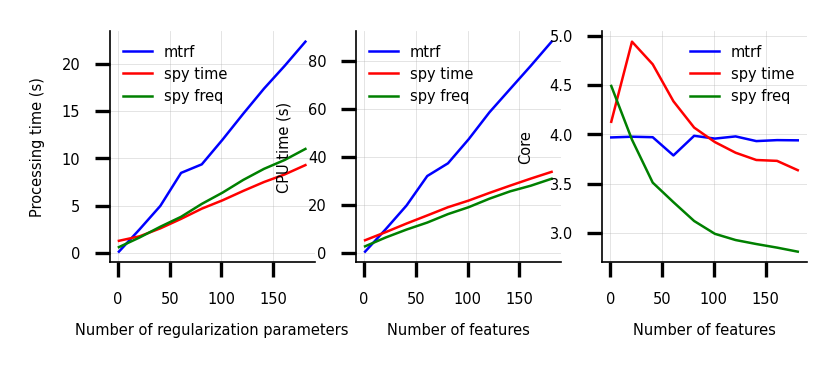

In [479]:
fig, ax = plt.subplots(1,3,figsize = (3,1))
ax[0].plot(list_nreg,t_mtrf, label = 'mtrf')
ax[0].plot(list_nreg,t_spyt, label = 'spy time')
ax[0].plot(list_nreg,t_spyf, label = 'spy freq')
ax[0].legend(framealpha = 0)
ax[0].set_xlabel('Number of regularization parameters')
ax[0].set_ylabel('Processing time (s)')

ax[1].plot(list_nreg,cpu_mtrf_l, label = 'mtrf')
ax[1].plot(list_nreg,cpu_spyt_l, label = 'spy time')
ax[1].plot(list_nreg,cpu_spyf_l, label = 'spy freq')
ax[1].legend(framealpha = 0)
ax[1].set_xlabel('Number of features')
ax[1].set_ylabel('Processing time (s)')
ax[1].set_ylabel('CPU time (s)')

ax[2].plot(list_nreg,core_mtrf_l, label = 'mtrf')
ax[2].plot(list_nreg,core_spyt_l, label = 'spy time')
ax[2].plot(list_nreg,core_spyf_l, label = 'spy freq')
ax[2].legend(framealpha = 0)
ax[2].set_xlabel('Number of features')
ax[2].set_ylabel('Processing time (s)')
ax[2].set_ylabel('Core')

### Relative to number of features

In [474]:
# Generate the Data without noise
fs = 50
n_feat = 30
n_channels = 64
T = 300
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)

tmin, tmax = -.5, 1
alphas = np.logspace(-5,5,10)
n_folds = 5
metrics = 'corr'

In [475]:
t_spyf, t_spyt, t_mtrf = [],[],[]
cpu_spyf_l, cpu_spyt_l, cpu_mtrf_l = [], [], []
core_spyf_l, core_spyt_l, core_mtrf_l = [], [], []
list_nfeat = np.arange(1,n_feat,2)
for i_feat in list_nfeat:
    X_feat = X[:,:i_feat]

    trf_spyt = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')
    w0_spyt = time.perf_counter()
    c0_spyt = time.process_time()
    scores_spyt = trf_spyt.xval_eval(X_feat, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyt = time.perf_counter()
    c1_spyt = time.process_time()
    wall_spyt = w1_spyt - w0_spyt
    cpu_spyt  = c1_spyt - c0_spyt

    trf_spyf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')
    w0_spyf = time.perf_counter()
    c0_spyf = time.process_time()
    scores_spyf = trf_spyf.xval_eval(X_feat, Y, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyf = time.perf_counter()
    c1_spyf = time.process_time()
    wall_spyf = w1_spyf - w0_spyf
    cpu_spyf  = c1_spyf - c0_spyf

    kf = KFold(n_splits=n_folds)
    X_fold, Y_fold = [], []
    for kfold, (train, test) in enumerate(kf.split(X_feat)):
        X_fold.append(X_feat[test,:])
        Y_fold.append(Y[test,:])

    fwd_trf = TRF(direction=1)
    regularization = alphas # regularization parameter lambda
    scores_mtrf = []
    w0_mtrf = time.perf_counter()
    c0_mtrf = time.process_time()
    for regularization in alphas:
        r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
    w1_mtrf = time.perf_counter()
    c1_mtrf = time.process_time()
    wall_mtrf = w1_mtrf - w0_mtrf
    cpu_mtrf  = c1_mtrf - c0_mtrf

    core_spyt_l.append(cpu_spyt / wall_spyt)
    core_spyf_l.append(cpu_spyf / wall_spyf)
    core_mtrf_l.append(cpu_mtrf / wall_mtrf)

    cpu_spyt_l.append(cpu_spyt)
    cpu_spyf_l.append(cpu_spyf)
    cpu_mtrf_l.append(cpu_mtrf)

    t_spyt.append(wall_spyt)
    t_spyf.append(wall_spyf)
    t_mtrf.append(wall_mtrf)

Text(0, 0.5, 'Core')

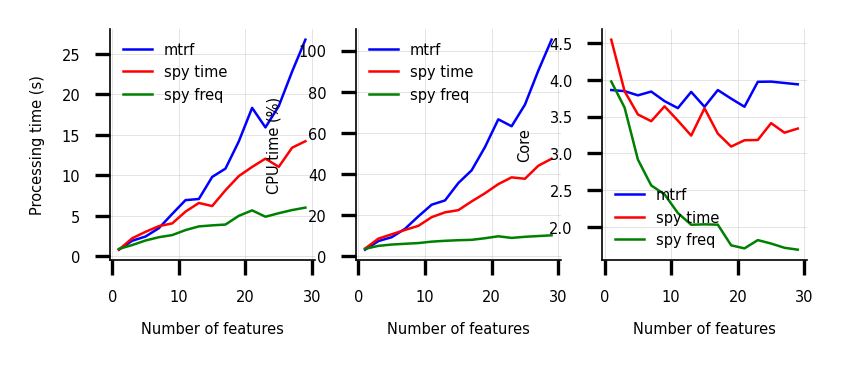

In [476]:
fig, ax = plt.subplots(1,3,figsize = (3,1))
ax[0].plot(list_nfeat,t_mtrf, label = 'mtrf')
ax[0].plot(list_nfeat,t_spyt, label = 'spy time')
ax[0].plot(list_nfeat,t_spyf, label = 'spy freq')
ax[0].legend(framealpha = 0)
ax[0].set_xlabel('Number of features')
ax[0].set_ylabel('Processing time (s)')

ax[1].plot(list_nfeat,cpu_mtrf_l, label = 'mtrf')
ax[1].plot(list_nfeat,cpu_spyt_l, label = 'spy time')
ax[1].plot(list_nfeat,cpu_spyf_l, label = 'spy freq')
ax[1].legend(framealpha = 0)
ax[1].set_xlabel('Number of features')
ax[1].set_ylabel('Processing time (s)')
ax[1].set_ylabel('CPU time (%)')

ax[2].plot(list_nfeat,core_mtrf_l, label = 'mtrf')
ax[2].plot(list_nfeat,core_spyt_l, label = 'spy time')
ax[2].plot(list_nfeat,core_spyf_l, label = 'spy freq')
ax[2].legend(framealpha = 0)
ax[2].set_xlabel('Number of features')
ax[2].set_ylabel('Processing time (s)')
ax[2].set_ylabel('Core')

### Relative to number of channels

In [459]:
# Generate the Data without noise
fs = 50
n_feat = 3
n_channels = 306
T = 300
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)

tmin, tmax = -.5, 1
alphas = np.logspace(-5,5,10)
n_folds = 5
metrics = 'corr'

In [460]:
t_spyf, t_spyt, t_mtrf = [],[],[]
cpu_spyf_l, cpu_spyt_l, cpu_mtrf_l = [], [], []
core_spyf_l, core_spyt_l, core_mtrf_l = [], [], []
list_nchan = np.arange(1,n_channels,20)
for i_chan in list_nchan:
    Y_chan = Y[:,:i_chan]

    trf_spyt = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')
    w0_spyt = time.perf_counter()
    c0_spyt = time.process_time()
    scores_spyt = trf_spyt.xval_eval(X, Y_chan, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyt = time.perf_counter()
    c1_spyt = time.process_time()
    wall_spyt = w1_spyt - w0_spyt
    cpu_spyt  = c1_spyt - c0_spyt

    trf_spyf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')
    w0_spyf = time.perf_counter()
    c0_spyf = time.process_time()
    scores_spyf = trf_spyf.xval_eval(X, Y_chan, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyf = time.perf_counter()
    c1_spyf = time.process_time()
    wall_spyf = w1_spyf - w0_spyf
    cpu_spyf  = c1_spyf - c0_spyf

    kf = KFold(n_splits=n_folds)
    X_fold, Y_fold = [], []
    for kfold, (train, test) in enumerate(kf.split(X)):
        X_fold.append(X[test,:])
        Y_fold.append(Y_chan[test,:])

    fwd_trf = TRF(direction=1)
    regularization = alphas # regularization parameter lambda
    scores_mtrf = []
    w0_mtrf = time.perf_counter()
    c0_mtrf = time.process_time()
    for regularization in alphas:
        r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
    w1_mtrf = time.perf_counter()
    c1_mtrf = time.process_time()
    wall_mtrf = w1_mtrf - w0_mtrf
    cpu_mtrf  = c1_mtrf - c0_mtrf

    core_spyt_l.append(cpu_spyt / wall_spyt)
    core_spyf_l.append(cpu_spyf / wall_spyf)
    core_mtrf_l.append(cpu_mtrf / wall_mtrf)

    cpu_spyt_l.append(cpu_spyt)
    cpu_spyf_l.append(cpu_spyf)
    cpu_mtrf_l.append(cpu_mtrf)

    t_spyt.append(wall_spyt)
    t_spyf.append(wall_spyf)
    t_mtrf.append(wall_mtrf)

Text(0, 0.5, 'CPU usage (%)')

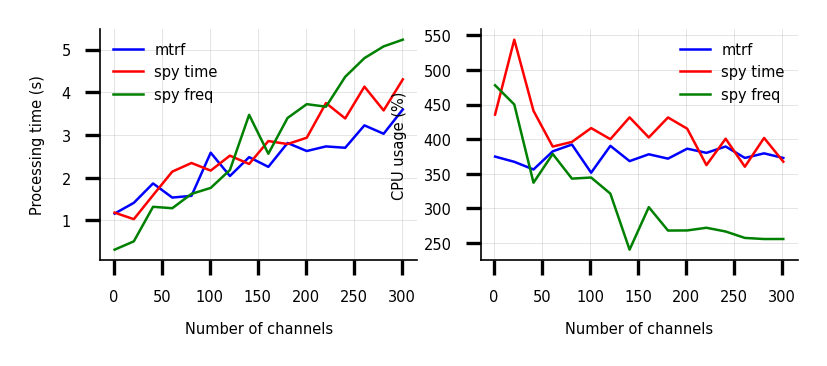

In [463]:
fig, ax = plt.subplots(1,2,figsize = (3,1))
ax[0].plot(list_nchan,t_mtrf, label = 'mtrf')
ax[0].plot(list_nchan,t_spyt, label = 'spy time')
ax[0].plot(list_nchan,t_spyf, label = 'spy freq')
ax[0].legend(framealpha = 0)
ax[0].set_xlabel('Number of channels')
ax[0].set_ylabel('Processing time (s)')

ax[1].plot(list_nchan,cpu_mtrf_l, label = 'mtrf')
ax[1].plot(list_nchan,cpu_spyt_l, label = 'spy time')
ax[1].plot(list_nchan,cpu_spyf_l, label = 'spy freq')
ax[1].legend(framealpha = 0)
ax[1].set_xlabel('Number of channels')
ax[1].set_ylabel('Processing time (s)')
ax[1].set_ylabel('CPU usage (%)')

### Relative to stimuli duration

In [429]:
# Generate the Data without noise
fs = 50
n_feat = 3
n_channels = 64
T = 3600
time_array, X, Y, events, impulse_responses = simulate_channels(n_feat = n_feat, n_channels = n_channels, fs = fs, T = T,
                                                              stim_type = 'continuous',
                                                              snr_db = -50, beta_noise = 0.4, 
                                                              impulse_freqs = [0.1,10], decreasing_rates = [1,20], 
                                                              delays = [0.00,0.2], 
                                                              filter_impulse = False, filter_val = [0.01,20],
                                                              random_seed = 0)

tmin, tmax = -.5, 1
alphas = np.logspace(-5,5,10)
n_folds = 5
metrics = 'corr'

In [456]:
t_spyf, t_spyt, t_mtrf = [],[],[]
cpu_spyf_l, cpu_spyt_l, cpu_mtrf_l = [], [], []
core_spyf_l, core_spyt_l, core_mtrf_l = [], [], []
list_duration = np.arange(1000,len(time_array),len(time_array) // 10)
for i_dur in list_duration:
    X_dur = X[:i_dur,:]
    Y_dur = Y[:i_dur,:]

    trf_spyt = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'time')
    w0_spyt = time.perf_counter()
    c0_spyt = time.process_time()
    scores_spyt = trf_spyt.xval_eval(X_dur, Y_dur, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyt = time.perf_counter()
    c1_spyt = time.process_time()
    wall_spyt = w1_spyt - w0_spyt
    cpu_spyt  = c1_spyt - c0_spyt


    trf_spyf = models.TRF.TRFEstimator(tmin=tmin, tmax=tmax, srate = fs, alpha = alphas, fit_domain = 'frequency')
    w0_spyf = time.perf_counter()
    c0_spyf = time.process_time()
    scores_spyf = trf_spyf.xval_eval(X_dur, Y_dur, n_splits = n_folds, scoring = metrics,verbose = False)
    w1_spyf = time.perf_counter()
    c1_spyf = time.process_time()
    wall_spyf = w1_spyf - w0_spyf
    cpu_spyf  = c1_spyf - c0_spyf

    kf = KFold(n_splits=n_folds)
    X_fold, Y_fold = [], []
    for kfold, (train, test) in enumerate(kf.split(X_dur)):
        X_fold.append(X_dur[test,:])
        Y_fold.append(Y_dur[test,:])

    fwd_trf = TRF(direction=1)
    regularization = alphas # regularization parameter lambda
    scores_mtrf = []
    w0_mtrf = time.perf_counter()
    c0_mtrf = time.process_time()
    for regularization in alphas:
        r_fwd = crossval(fwd_trf, X_fold, Y_fold, fs, tmin, tmax, regularization, average = False, verbose = False)
    w1_mtrf = time.perf_counter()
    c1_mtrf = time.process_time()
    wall_mtrf = w1_mtrf - w0_mtrf
    cpu_mtrf  = c1_mtrf - c0_mtrf

    core_spyt_l.append(cpu_spyt / wall_spyt)
    core_spyf_l.append(cpu_spyf / wall_spyf)
    core_mtrf_l.append(cpu_mtrf / wall_mtrf)

    cpu_spyt_l.append(cpu_spyt)
    cpu_spyf_l.append(cpu_spyf)
    cpu_mtrf_l.append(cpu_mtrf)

    t_spyt.append(wall_spyt)
    t_spyf.append(wall_spyf)
    t_mtrf.append(wall_mtrf)

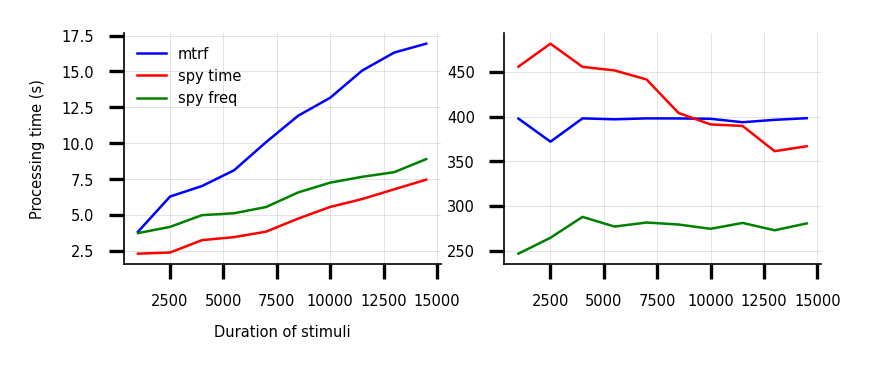

In [457]:
fig, ax = plt.subplots(1,3,figsize = (3,1))
ax[0].plot(list_duration,t_mtrf, label = 'mtrf')
ax[0].plot(list_duration,t_spyt, label = 'spy time')
ax[0].plot(list_duration,t_spyf, label = 'spy freq')
ax[0].legend(framealpha = 0)
ax[0].set_xlabel('Duration of stimuli')
ax[0].set_ylabel('Processing time (s)')


ax[1].plot(list_duration,cpu_mtrf_l, label = 'mtrf')
ax[1].plot(list_duration,cpu_spyt_l, label = 'spy time')
ax[1].plot(list_duration,cpu_spyf_l, label = 'spy freq')

ax[2].plot(list_duration,core_mtrf_l, label = 'mtrf')
ax[2].plot(list_duration,core_spyt_l, label = 'spy time')
ax[2].plot(list_duration,core_spyf_l, label = 'spy freq')